### Case Study: Interpolation vs SVI for Risk-Neutral Density Recovery

This notebook evaluates how different implied volatility representations affect
risk-neutral density recovery using the Breeden–Litzenberger formula.

We compare:

- Local interpolation methods (PCHIP, Cubic Spline, Akima)
- Parametric SVI volatility calibration

using a real market option chain of AAPL.

In [2]:
import datetime

import matplotlib.pyplot as plt
import numpy as np

from optionanalytics.data.yahoo import fetch_option_chain
from optionanalytics.cleaning.filters import clean_option_chain
from optionanalytics.cleaning.arbitrage import filter_price_bound_violations

from optionanalytics.models.market import MarketData
from optionanalytics.models.enums import (
    InterpolationMethod,
    VolatilityModel,
)

from optionanalytics.volatility.smile import build_smile
from optionanalytics.density.risk_neutral import build_density

#### Market Setup

We download a listed option chain from Yahoo Finance and construct an implied
volatility smile after filtering invalid quotes and static arbitrage violations.

In [3]:
ticker = "AAPL"
expiry = "2026-08-21"

valuation_date = datetime.date(2026, 7, 18)

market_data = MarketData(
    spot=333.74,
    risk_free_rate=0.0418,
    volatility=0.20,
)

chain = fetch_option_chain(
    ticker,
    expiry,
)

chain = clean_option_chain(chain)

chain = filter_price_bound_violations(
    chain,
    market_data,
    valuation_date,
)

smile = build_smile(
    chain,
    market_data,
    valuation_date,
)

#### Market Implied Volatility Smile

The smile below is constructed directly from market option prices after
cleaning and implied volatility inversion.

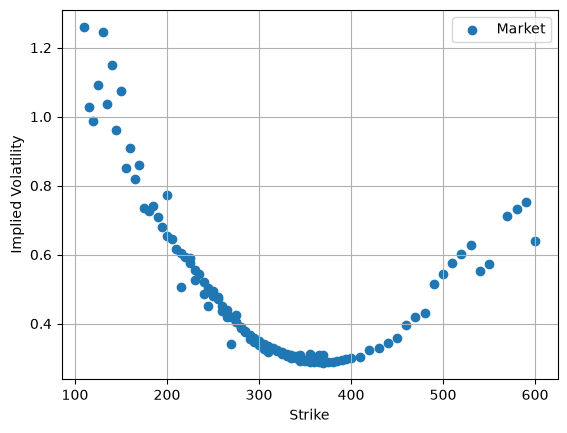

In [7]:
plt.scatter(
    [p.strike for p in smile.points],
    [p.implied_volatility for p in smile.points],
    label="Market",
)

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")

plt.grid(True)
plt.legend()

#### Density Recovery

The same implied volatility smile is now represented using different volatility
models.

Each representation is converted into option prices using Black–Scholes and
then differentiated using the Breeden–Litzenberger formula to recover the
risk-neutral probability density.

In [8]:
density_pchip = build_density(
    smile,
    market_data,
    valuation_date,
    interpolation_method=InterpolationMethod.PCHIP,
)

density_akima = build_density(
    smile,
    market_data,
    valuation_date,
    interpolation_method=InterpolationMethod.AKIMA,
)

density_cubic = build_density(
    smile,
    market_data,
    valuation_date,
    interpolation_method=InterpolationMethod.CUBIC_SPLINE,
)

density_svi = build_density(
    smile,
    market_data,
    valuation_date,
    volatility_model=VolatilityModel.SVI,
)

#### Recovered Risk-Neutral Densities

A valid probability density should

- remain smooth,
- remain non-negative, and
- integrate to one.

The figure below compares densities recovered using interpolation-based smiles
and a calibrated SVI model.

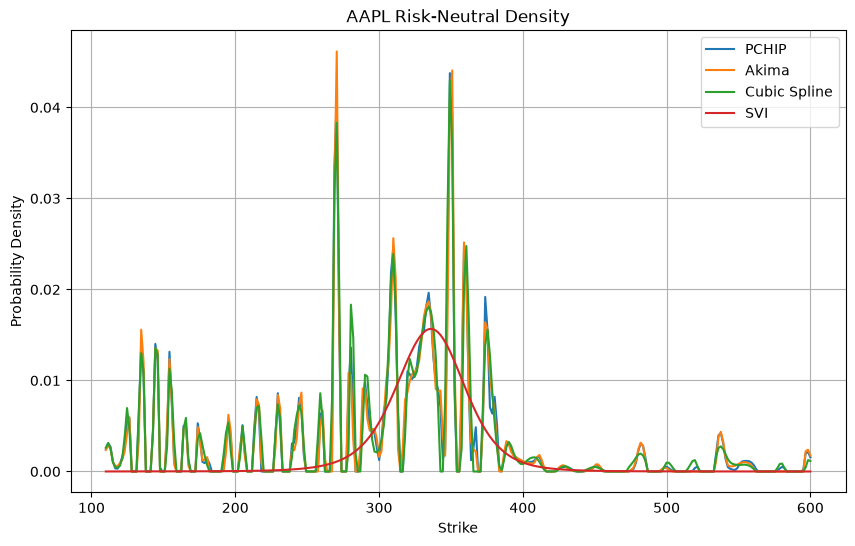

In [9]:
plt.figure(figsize=(10, 6))

for density, label in [
    (density_pchip, "PCHIP"),
    (density_akima, "Akima"),
    (density_cubic, "Cubic Spline"),
    (density_svi, "SVI"),
]:
    plt.plot(
        [p.strike for p in density.points],
        [p.probability_density for p in density.points],
        label=label,
    )

plt.xlabel("Strike")
plt.ylabel("Probability Density")
plt.title(f"{ticker} Risk-Neutral Density")
plt.grid(True)
plt.legend()

Text(0.5, 1.0, 'TSLA Risk-Neutral Density (SVI)')

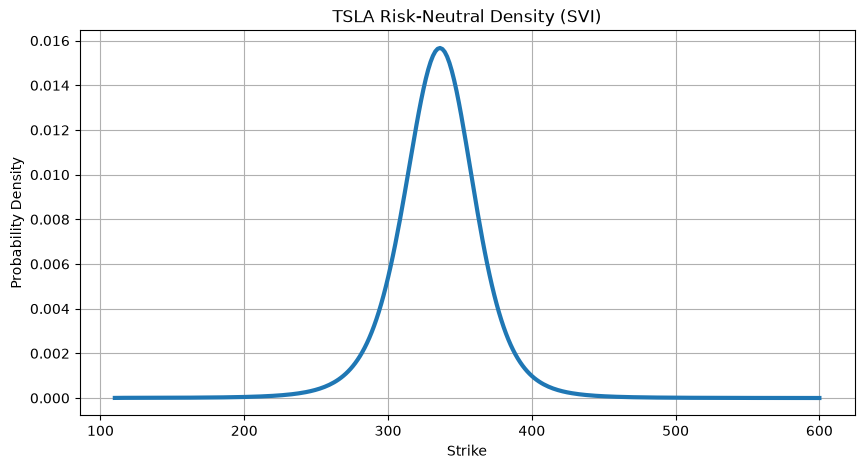

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    [p.strike for p in density_svi.points],
    [p.probability_density for p in density_svi.points],
    linewidth=3,
)

plt.grid(True)
plt.xlabel("Strike")
plt.ylabel("Probability Density")
plt.title("TSLA Risk-Neutral Density (SVI)")

#### Probability Mass

The recovered density should integrate to approximately one.

We numerically integrate each density to compare the stability of the different
volatility representations.

In [10]:
def probability_mass(density):
    strikes = np.array([p.strike for p in density.points])
    pdf = np.array([p.probability_density for p in density.points])
    return np.trapezoid(pdf, strikes)

for density, label in [
    (density_pchip, "PCHIP"),
    (density_akima, "Akima"),
    (density_cubic, "Cubic"),
    (density_svi, "SVI"),
]:
    print(f"{label:12s}: {probability_mass(density):.6f}")

PCHIP       : 1.695110
Akima       : 1.683919
Cubic       : 1.734836
SVI         : 0.999436


### Conclusion

This case study demonstrates that recovering risk-neutral densities is considerably more sensitive than constructing implied volatility smiles.

While interpolation methods provide accurate local fits to market implied volatilities, numerical differentiation amplifies small oscillations, leading to unstable probability densities that violate basic probabilistic properties.

Calibrating an SVI volatility model produces a globally smooth total variance function, resulting in a stable Breeden–Litzenberger density with probability mass approximately equal to one.

These results motivate the use of arbitrage-aware parametric volatility models for implied distribution recovery and subsequent quantitative analysis.